**<h1>AHJ Database: California Built Environment Personnel Mapping 2025**
#### Analysis 2.v4 =  Analysis 2 (filtered GCC data) + Geomap
<i>Any question regarding the notebook, please contact Robert Ford<br>
    Last Updated: 06/25/2025</i>
* AHJ Data: City and County level data sourced from Government Compensation California (GCC)
* Geo Data: Various open source databases including state and federal - ranging from census, ArcGIS, and other open sources
* Started development on 06/25/2025
* Finished Iteration on -06/25/2025-

In [103]:
# Run once for pip installs and upgrades
#%pip install --upgrade pip


In [104]:
# Import and load libs and packages
import pandas as pd
import re
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import nltk
from nltk.corpus import stopwords
from rapidfuzz import process, fuzz

# Download NLTK stopwords
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rford\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [105]:
# Load base dataset here
df = pd.read_excel("2023_City.xlsx")

# Split into training (30%) and test (70%)
train_df = df.sample(frac=0.3, random_state=42)
test_df = df.drop(train_df.index)

In [106]:
# Keywords to KEEP
keep_dept_keywords = [
    "Planning", "Community Development", "Building Department", "Code Compliance",
    "Public Works", "Streets", "Engineering", "Construction", "Zoning"
]

keep_position_keywords = [
    "Construction", "Building", "HVAC", "Plans Inspector", "Zoning Investigator",
    "Architect", "Permit Technician", "Safety Inspector", "Planner", "Code Enforcer",
    "Plan Check Coordinator", "Licensing Specialist", "Community Development Technician"
]

# Keywords to FILTER OUT
filter_dept_keywords = [
    "Administration", "Communications", "Animal", "Finance", "Community Services",
    "Municipal Power", "Base Reuse", "City Attorney", "City Clerk", "Council", "Fire",
    "Human Resources", "Library", "IT", "Police", "Recreation", "Government Services",
    "Facilities", "Water", "Power", "Airport", "Health", "Zero Waste", "Sewer",
    "Equipment", "Transfer Station", "Janitor", "Landscaping", "Utilities", "Business",
    "Transit", "Nutrition", "Aging", "Adult", "Youth", "Homeless", "Athletics", "Law",
    "Attorney", "Management"
]

filter_position_keywords = [
    "Fitness instructor", "Recreational Leader", "Librarian", "Admin", "Clerk",
    "Secretary", "Parking Officer", "Police", "Firefighter", "Treasurer", "Employment Worker",
    "Lifeguard", "Animal", "Recycling", "Sewer", "Finance", "HR", "IT", "Parks & Rec",
    "Health", "EMT", "Custodian", "Equipment Mechanic", "Aquatics", "Traffic",
    "Community Service", "Veterinary", "Senior Citizen", "Pool", "Utilities", "Audio",
    "Communications", "Mayor", "Attendant", "Vocational Worker", "Messenger Clerk",
    "Customer Service", "Truck Operator", "Sanitation", "Painter", "Eltl Engr Assoc",
    "Laborer", "Program Assistant"
]


In [107]:
# Helper function to match keywords
def keyword_match(text, keywords):
    if pd.isna(text):
        return False
    return any(re.search(rf'\b{re.escape(k)}\b', str(text), re.IGNORECASE) for k in keywords)

# Label rows for training
def label_row(row):
    keep_dept = keyword_match(row['DepartmentOrSubdivision'], keep_dept_keywords)
    keep_pos = keyword_match(row['Position'], keep_position_keywords)
    filter_dept = keyword_match(row['DepartmentOrSubdivision'], filter_dept_keywords)
    filter_pos = keyword_match(row['Position'], filter_position_keywords)
    return int((keep_dept or keep_pos) and not (filter_dept or filter_pos))


In [108]:
# Apply labeling
train_df["label"] = train_df.apply(label_row, axis=1)

# Combine text for model training
train_df["combined_text"] = train_df["DepartmentOrSubdivision"].fillna('') + " " + train_df["Position"].fillna('')

# Show label distribution
train_df["label"].value_counts()


label
0    91664
1    11646
Name: count, dtype: int64

In [109]:
# Feature and Target Preparation

X = train_df["combined_text"]
y = train_df["label"]


In [110]:
# Create pipeline with TF-IDF + Logistic Regression
model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words=stopwords.words('english'), max_features=1000)),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
# Train model
model.fit(X, y)


,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [111]:
# Combine text columns
test_df["combined_text"] = test_df["DepartmentOrSubdivision"].fillna('') + " " + test_df["Position"].fillna('')

# Predict using the trained model
test_df["predicted_label"] = model.predict(test_df["combined_text"])

# Filter the results
filtered_df = test_df[test_df["predicted_label"] == 1]

# Display summary
print(f"Filtered rows: {len(filtered_df)} / {len(test_df)}")
filtered_df.head()


Filtered rows: 27553 / 241056


,Year,EmployerType,EmployerName,DepartmentOrSubdivision,Position,ElectedOfficial,Judicial,OtherPositions,MinPositionSalary,MaxPositionSalary,...,PensionFormula,EmployerURL,EmployerPopulation,LastUpdatedDate,EmployerCounty,SpecialDistrictActivities,IncludesUnfundedLiability,SpecialDistrictType,combined_text,predicted_label
35,2023,City,Adelanto,Streets,Maint Worker I,False,False,NaN,44363.0,49931.0,...,2%@62,https://www.ci.adelanto.ca.us/198/Human-Resources,36131,2024-06-25,San Bernardino,NaN,False,NaN,Streets Maint Worker I,1
36,2023,City,Adelanto,Streets,Maint Worker III,False,False,NaN,58955.0,66354.0,...,2%@60,https://www.ci.adelanto.ca.us/198/Human-Resources,36131,2024-06-25,San Bernardino,NaN,False,NaN,Streets Maint Worker III,1
37,2023,City,Adelanto,Streets,Maint Worker III,False,False,NaN,58955.0,66354.0,...,2%@60,https://www.ci.adelanto.ca.us/198/Human-Resources,36131,2024-06-25,San Bernardino,NaN,False,NaN,Streets Maint Worker III,1
38,2023,City,Adelanto,Streets,Maint Worker III,False,False,NaN,58955.0,66354.0,...,2%@60,https://www.ci.adelanto.ca.us/198/Human-Resources,36131,2024-06-25,San Bernardino,NaN,False,NaN,Streets Maint Worker III,1
58,2023,City,Agoura Hills,Community Development,Associate Planner,False,False,NaN,98041.0,119454.0,...,2%@55,https://www.agourahillscity.org/department/hum...,19841,2024-06-25,Los Angeles,NaN,False,NaN,Community Development Associate Planner,1


In [112]:
# Visual Checks of headers for personnel data and geodata 
#print(ca_personnel.head())
#print(ca_personnel.columns)


In [113]:
# Cleaning function
def clean_name(name):
    name = str(name).strip().lower()
    return name.title() if name else ''

# Clean columns for joining
filtered_df['clean_city_name'] = filtered_df['EmployerName'].apply(clean_name)
filtered_df['clean_county_name'] = filtered_df['EmployerCounty'].apply(clean_name)


C:\Users\Rford\AppData\Local\Temp\ipykernel_47864\2798458203.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['clean_city_name'] = filtered_df['EmployerName'].apply(clean_name)
C:\Users\Rford\AppData\Local\Temp\ipykernel_47864\2798458203.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['clean_county_name'] = filtered_df['EmployerCounty'].apply(clean_name)


In [114]:
# Filters: Empty if not needed

# Specify the city to exclude
excluded_cities = ["Los Angeles"]
# Specify the county to exclude
excluded_counties = ["Los Angeles"]


In [115]:
# Aggregate and filter 
agg_city_counts = filtered_df.groupby('clean_city_name').size().reset_index(name='personnel_count_city')
agg_county_counts = filtered_df.groupby('clean_county_name').size().reset_index(name='personnel_count_county')

filtered_city = filtered_df[~filtered_df['clean_city_name'].isin(excluded_cities)]
filtered_county = filtered_df[~filtered_df['clean_county_name'].isin(excluded_counties)]

agg_city_counts_filtered = filtered_city.groupby('clean_city_name').size().reset_index(name='personnel_count_city')
agg_county_counts_filtered = filtered_county.groupby('clean_county_name').size().reset_index(name='personnel_count_county')

# Check the aggregated personnel count for cities and counties
#agg_city_counts
#agg_city_counts_filtered
#agg_county_counts
#agg_county_counts_filtered
#filtered_city
#filtered_county



In [116]:
# Bin ranges
agg_city_counts['city_personnel_bin'] = pd.cut(
    agg_city_counts['personnel_count_city'],
    bins=[0, 100, 1000, 5000, float('inf')],
    labels=['0–100', '100–1000', '1000–5000', '5000+'],
    right=False
)

agg_county_counts['county_personnel_bin'] = pd.cut(
    agg_county_counts['personnel_count_county'],
    bins=[0, 100, 1000, 5000, float('inf')],
    labels=['0–100', '100–1000', '1000–5000', '5000+'],
    right=False
)


In [117]:
# Read Files and load data
ca_geo_df = gpd.read_file("City_and_County_Boundary_Line_Changes_-3971126187329447856/BOE_CityCounty.shp")
county_geo = gpd.read_file("California_County_Boundaries_and_Identifiers_Blue_Version_view_2716745428963682036/California_County_Boundaries_and_Identifiers.shp")


In [118]:
# City maps (full + filtered)
geo_city = ca_geo_df.copy()
geo_city['clean_name'] = geo_city['CITY'].apply(clean_name)
geo_city = geo_city.merge(
    agg_city_counts[['clean_city_name', 'personnel_count_city', 'city_personnel_bin']],
    left_on='clean_name',
    right_on='clean_city_name',
    how='left'
)

geo_city['personnel_count_city'] = geo_city['personnel_count_city'].fillna(0)

# Merge all needed data
geo_city_filtered = ca_geo_df.copy()
geo_city_filtered['clean_name'] = geo_city_filtered['CITY'].apply(clean_name)

geo_city_filtered = geo_city_filtered.merge(
    agg_city_counts_filtered,
    left_on='clean_name',
    right_on='clean_city_name',
    how='left'
)

# Fill missing values for plotting
geo_city_filtered['personnel_count_city'] = geo_city_filtered['personnel_count_city'].fillna(0)



In [119]:
# Merge with county_geo: Full
county_geo['clean_name'] = county_geo['CDT_NAME_S'].apply(clean_name)

geo_county = county_geo.merge(
    agg_county_counts[['clean_county_name', 'personnel_count_county', 'county_personnel_bin']],
    left_on='clean_name',
    right_on='clean_county_name',
    how='left'
)
geo_county['personnel_count_county'] = geo_county['personnel_count_county'].fillna(0)

# Merge with county_geo: Filtered
geo_county_filtered = county_geo.merge(
    agg_county_counts_filtered,
    left_on='clean_name',
    right_on='clean_county_name',
    how='left'
)

# Fill missing personnel counts with 0
geo_county_filtered['personnel_count_county'] = geo_county_filtered['personnel_count_county'].fillna(0)

In [120]:
# Checks for geomaps
#geo_city
#geo_city_filtered
#geo_county
#geo_county_filtered

In [121]:
# Defining plotting function

def plot_personnel_map(gdf, column, title, cmap='YlGnBu'):
    fig, ax = plt.subplots(1, 1, figsize=(14, 14))
    gdf.plot(
        column=column,
        cmap=cmap,
        linewidth=0.5,
        edgecolor='black',
        legend=True,
        ax=ax,
        missing_kwds={"color": "lightgrey", "label": "Missing data"}
    )
    legend = ax.get_legend()
    if legend:
        legend.set_title(title)

    ax.set_title(title, fontsize=16)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


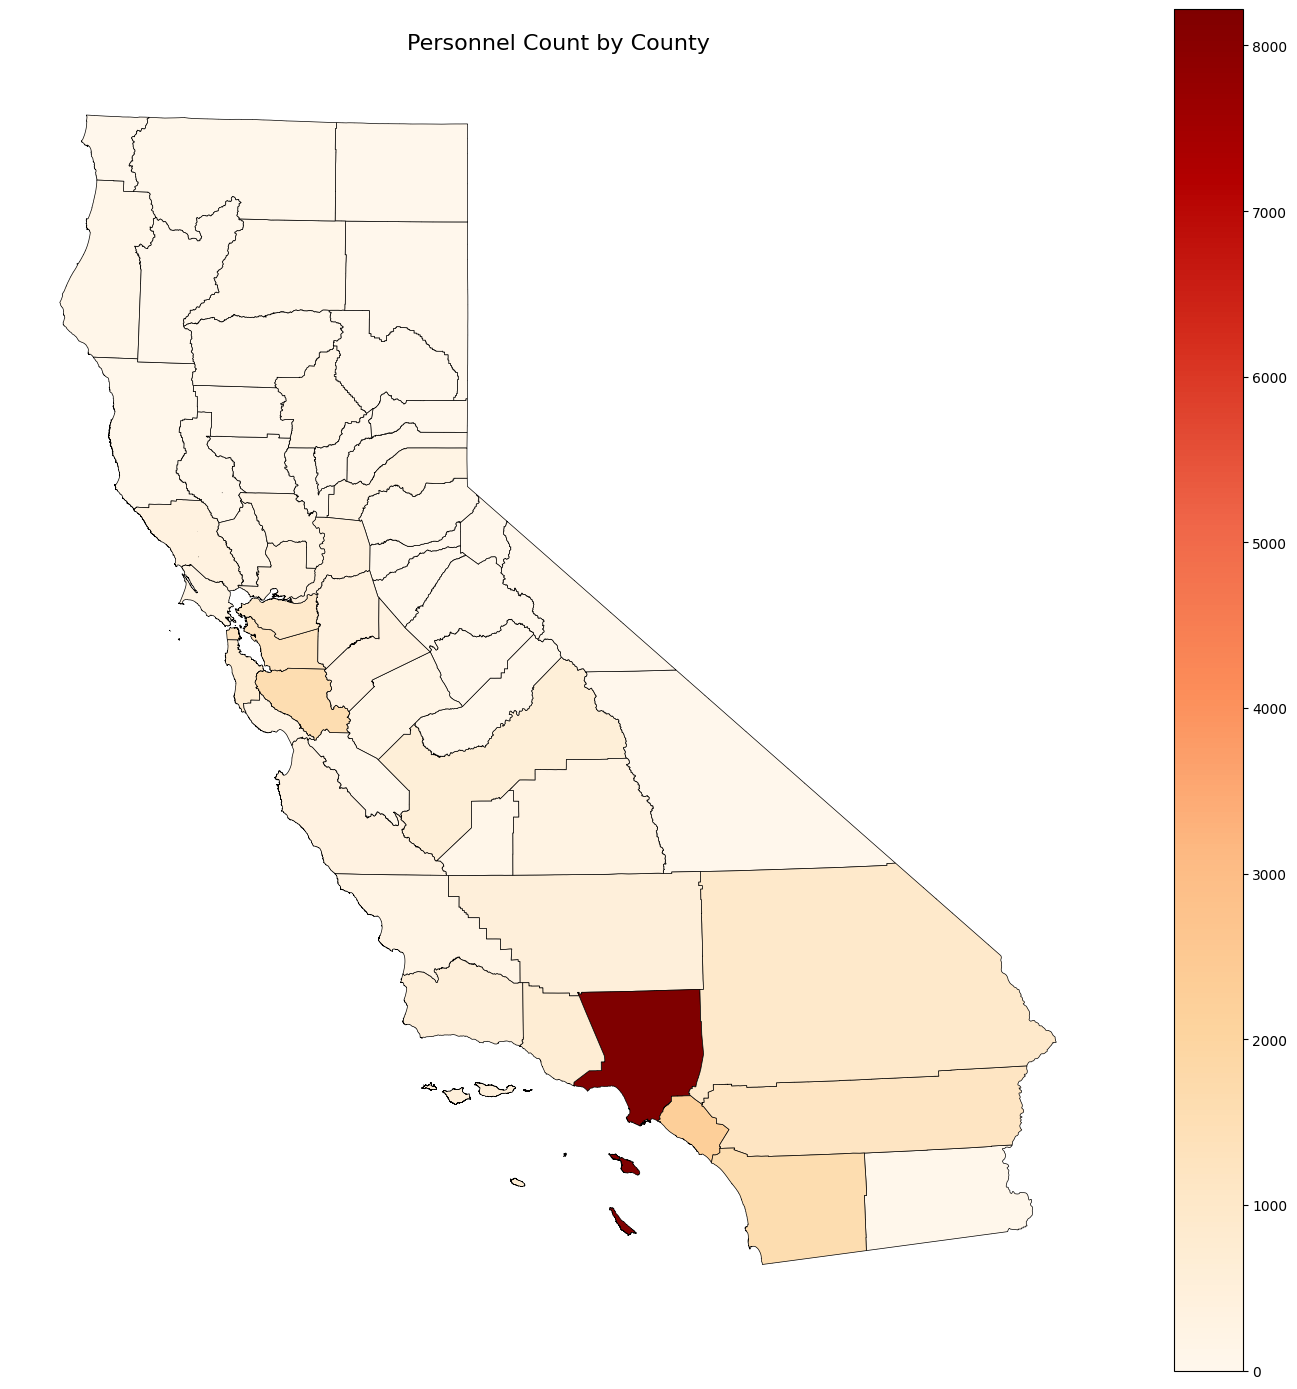

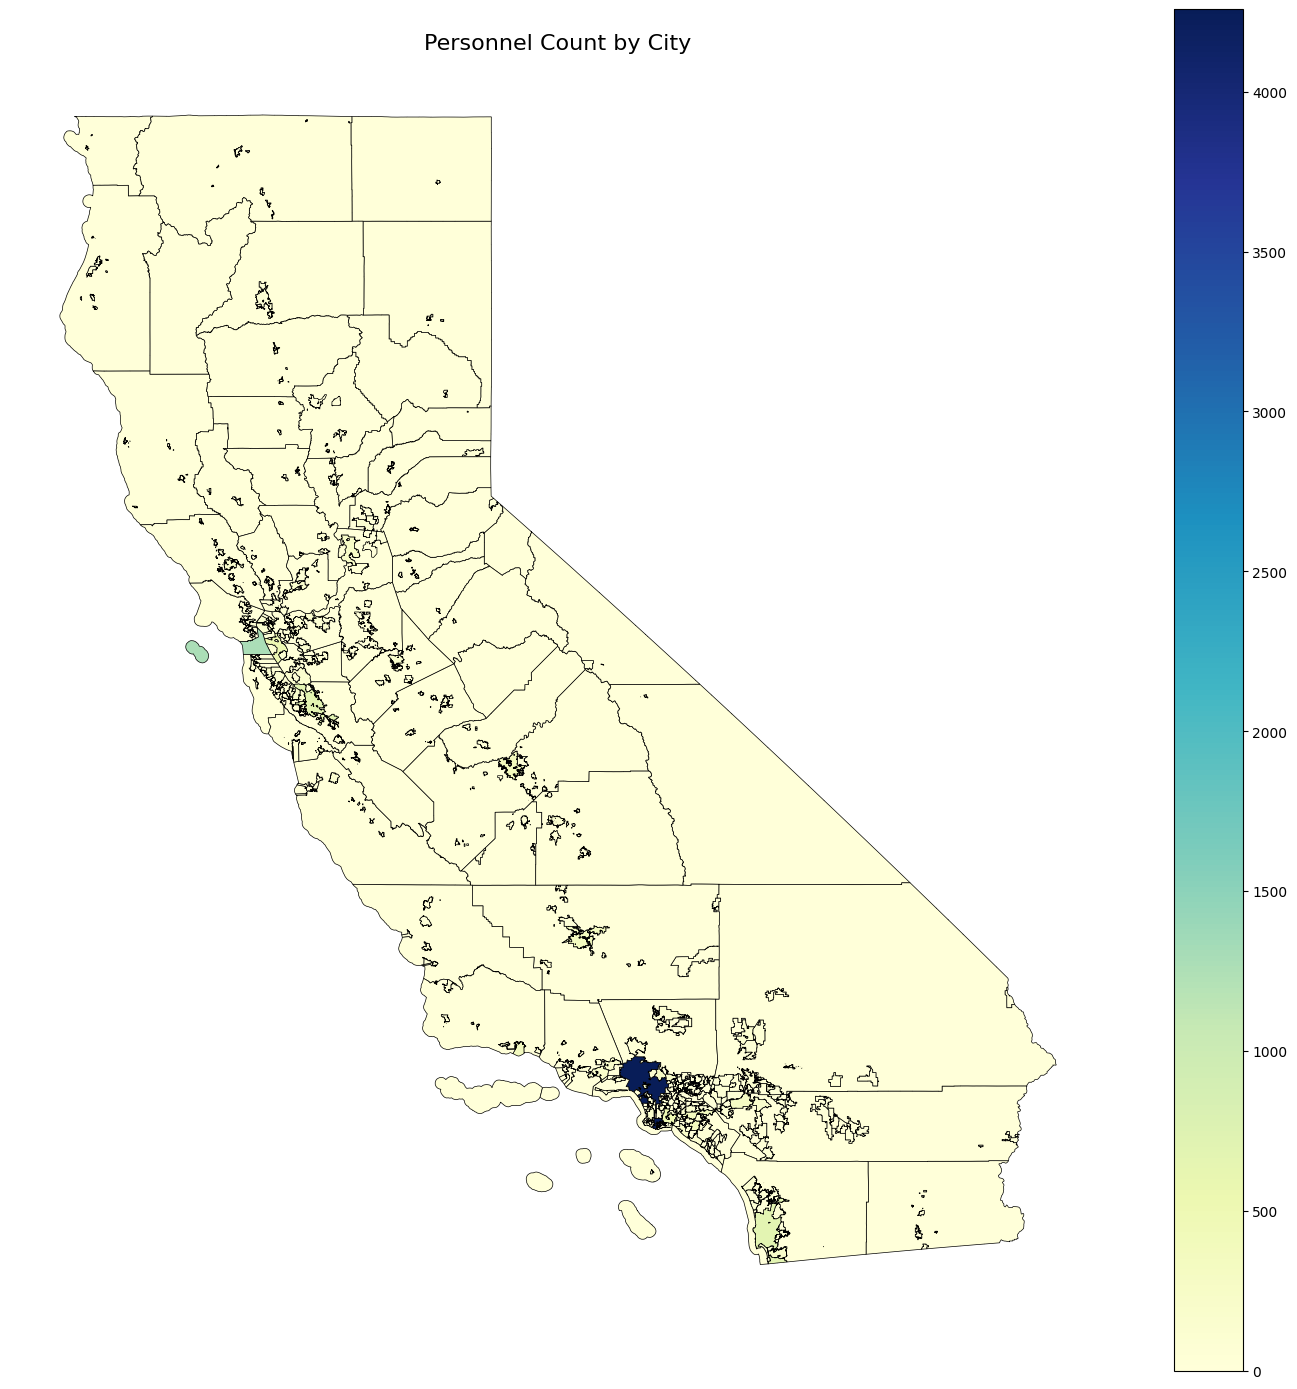

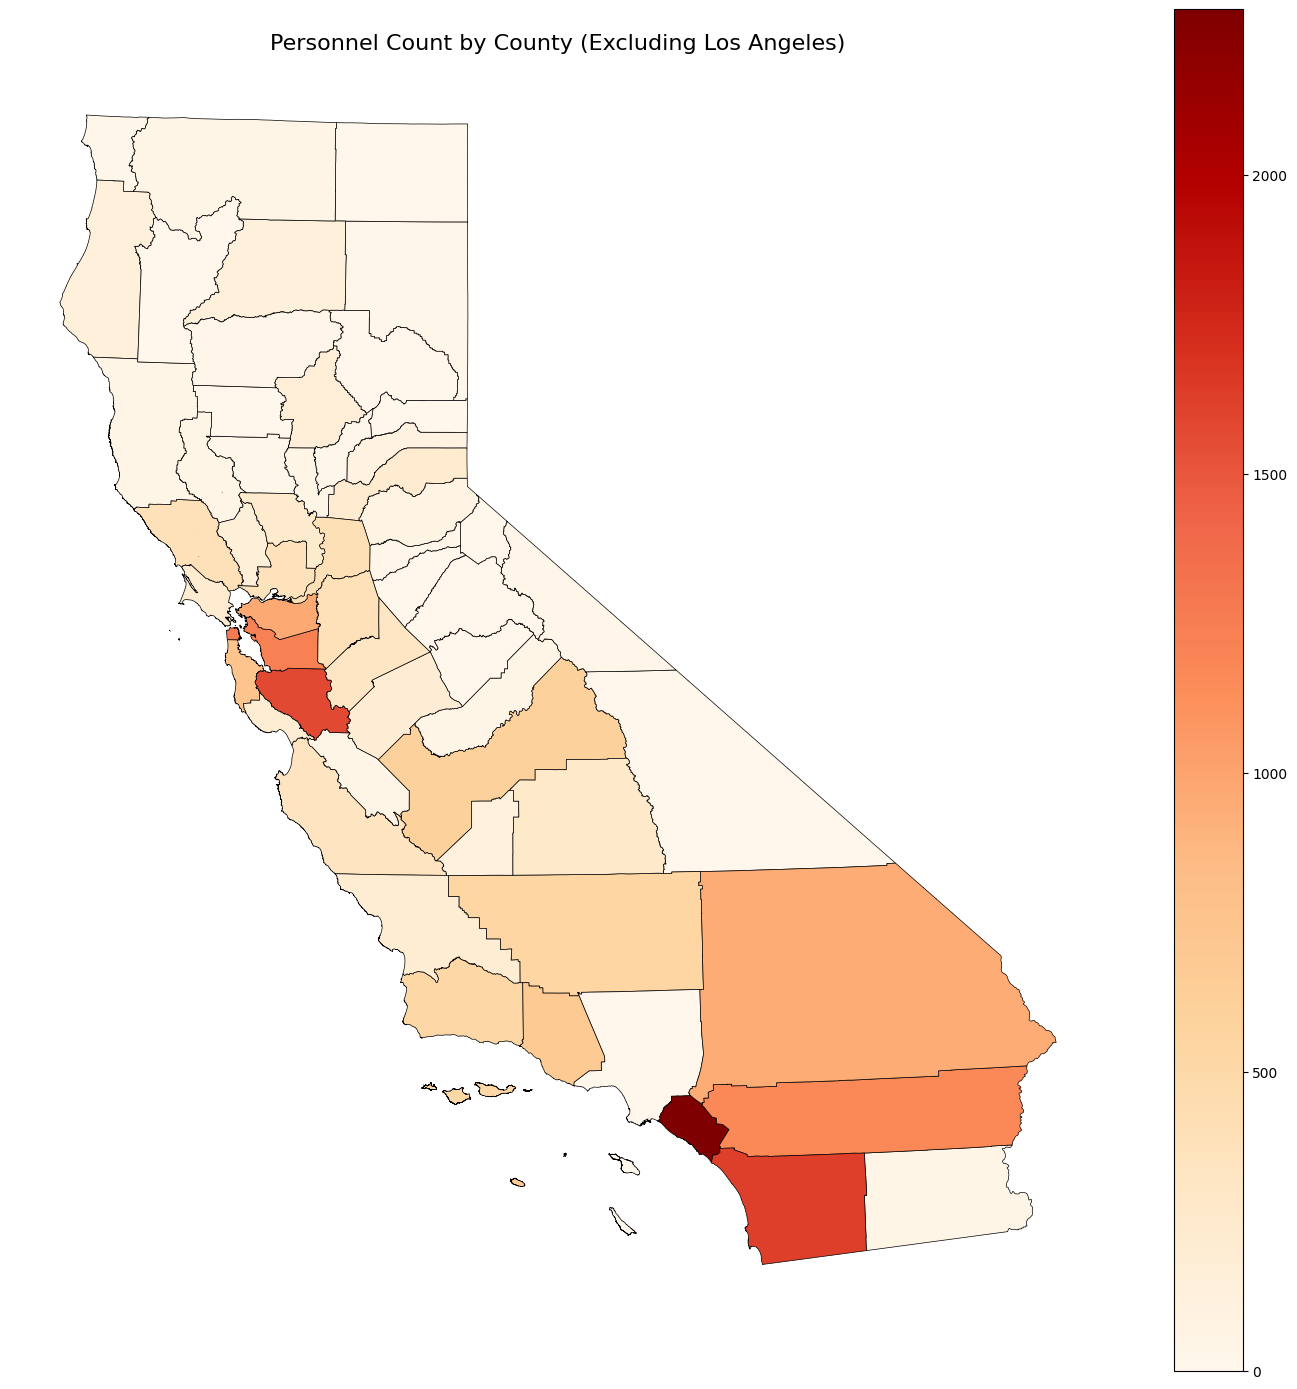

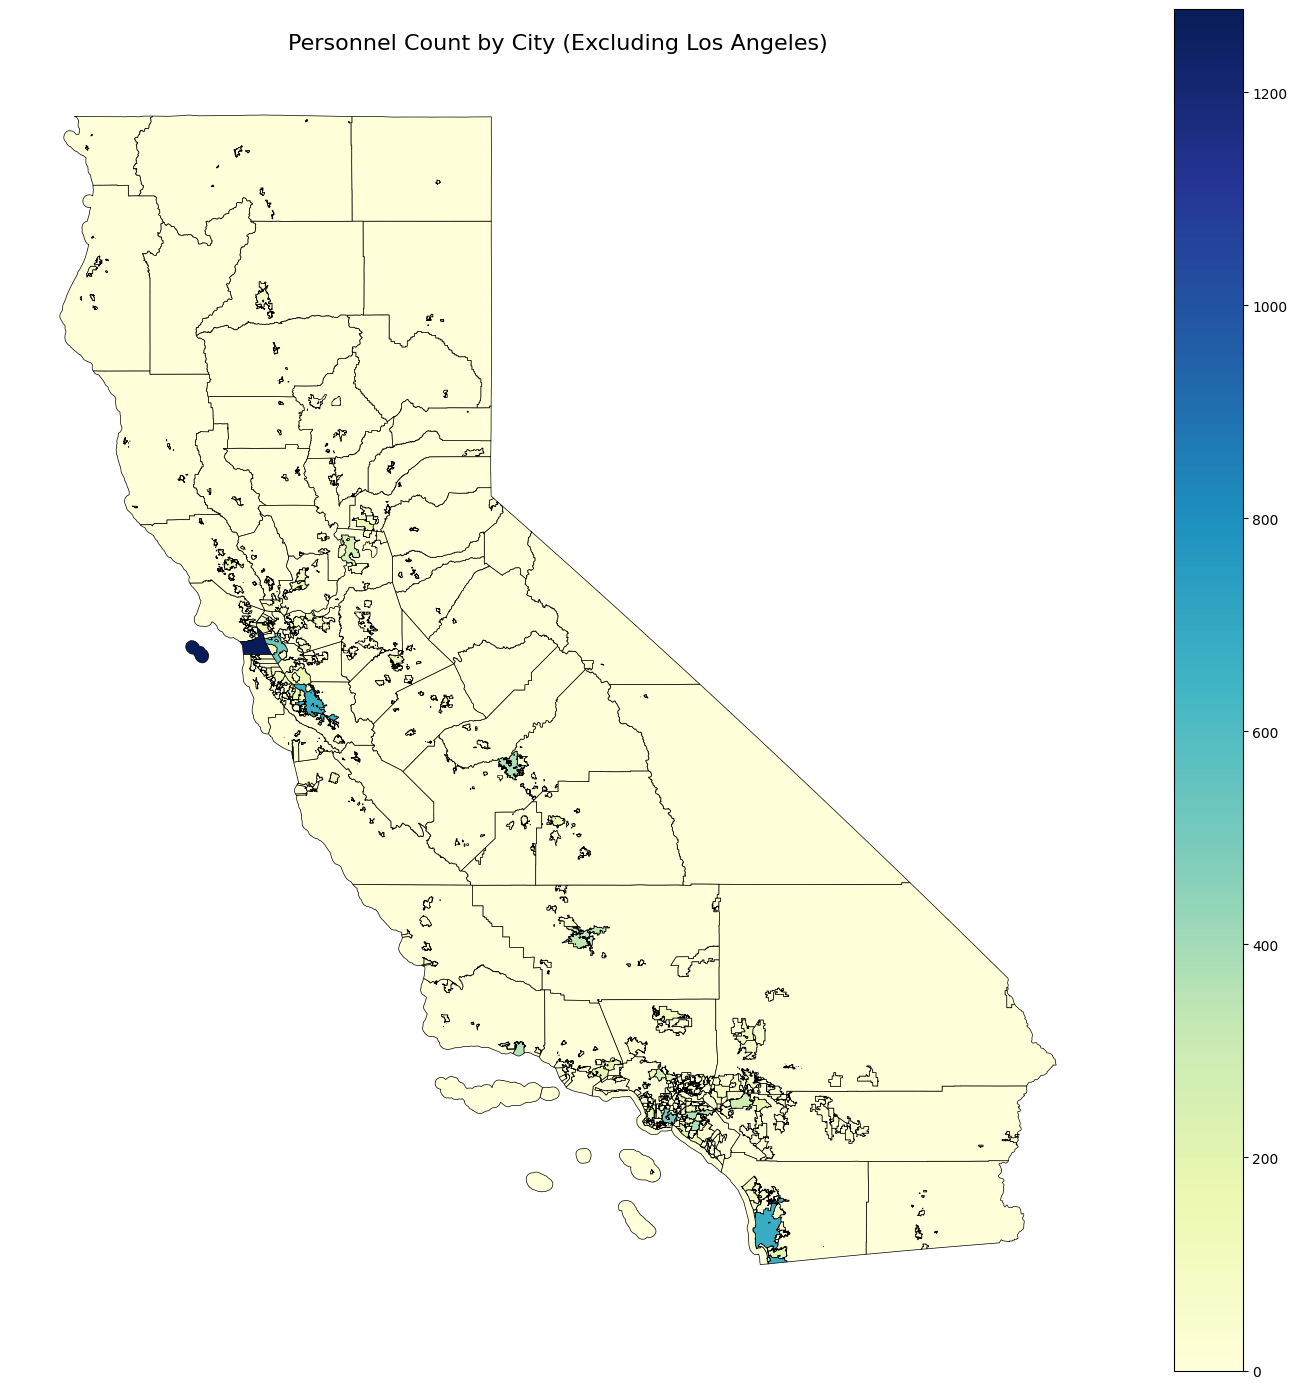

In [122]:
# Plot all maps

# County - All
plot_personnel_map(
    geo_county,
    column='personnel_count_county',
    title='Personnel Count by County',
    cmap='OrRd'
)

# City - All
plot_personnel_map(
    geo_city,
    column='personnel_count_city',
    title='Personnel Count by City',
    cmap='YlGnBu'
)

# County - Excluding Los Angeles
plot_personnel_map(
    geo_county_filtered,
    column='personnel_count_county',
    title = f"Personnel Count by County (Excluding {', '.join(excluded_counties)})",
    cmap='OrRd'
)

# City - Excluding Los Angeles
plot_personnel_map(
    geo_city_filtered,
    column='personnel_count_city',
    title = f"Personnel Count by City (Excluding {', '.join(excluded_cities)})",
    cmap='YlGnBu'
)



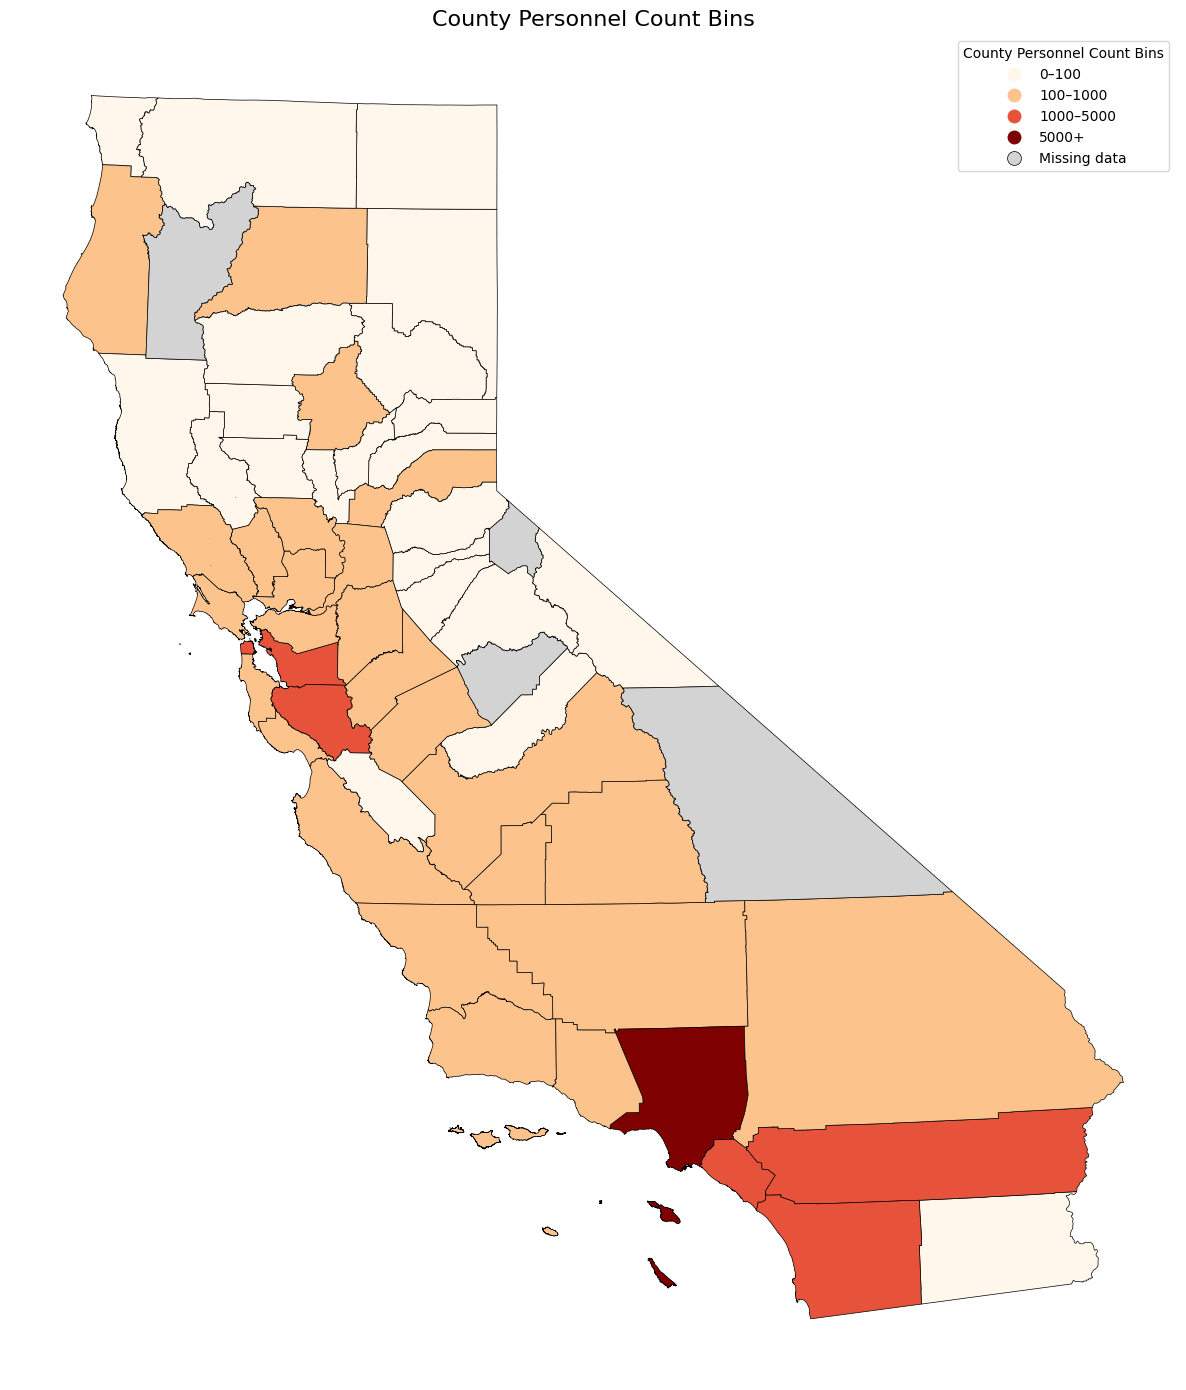

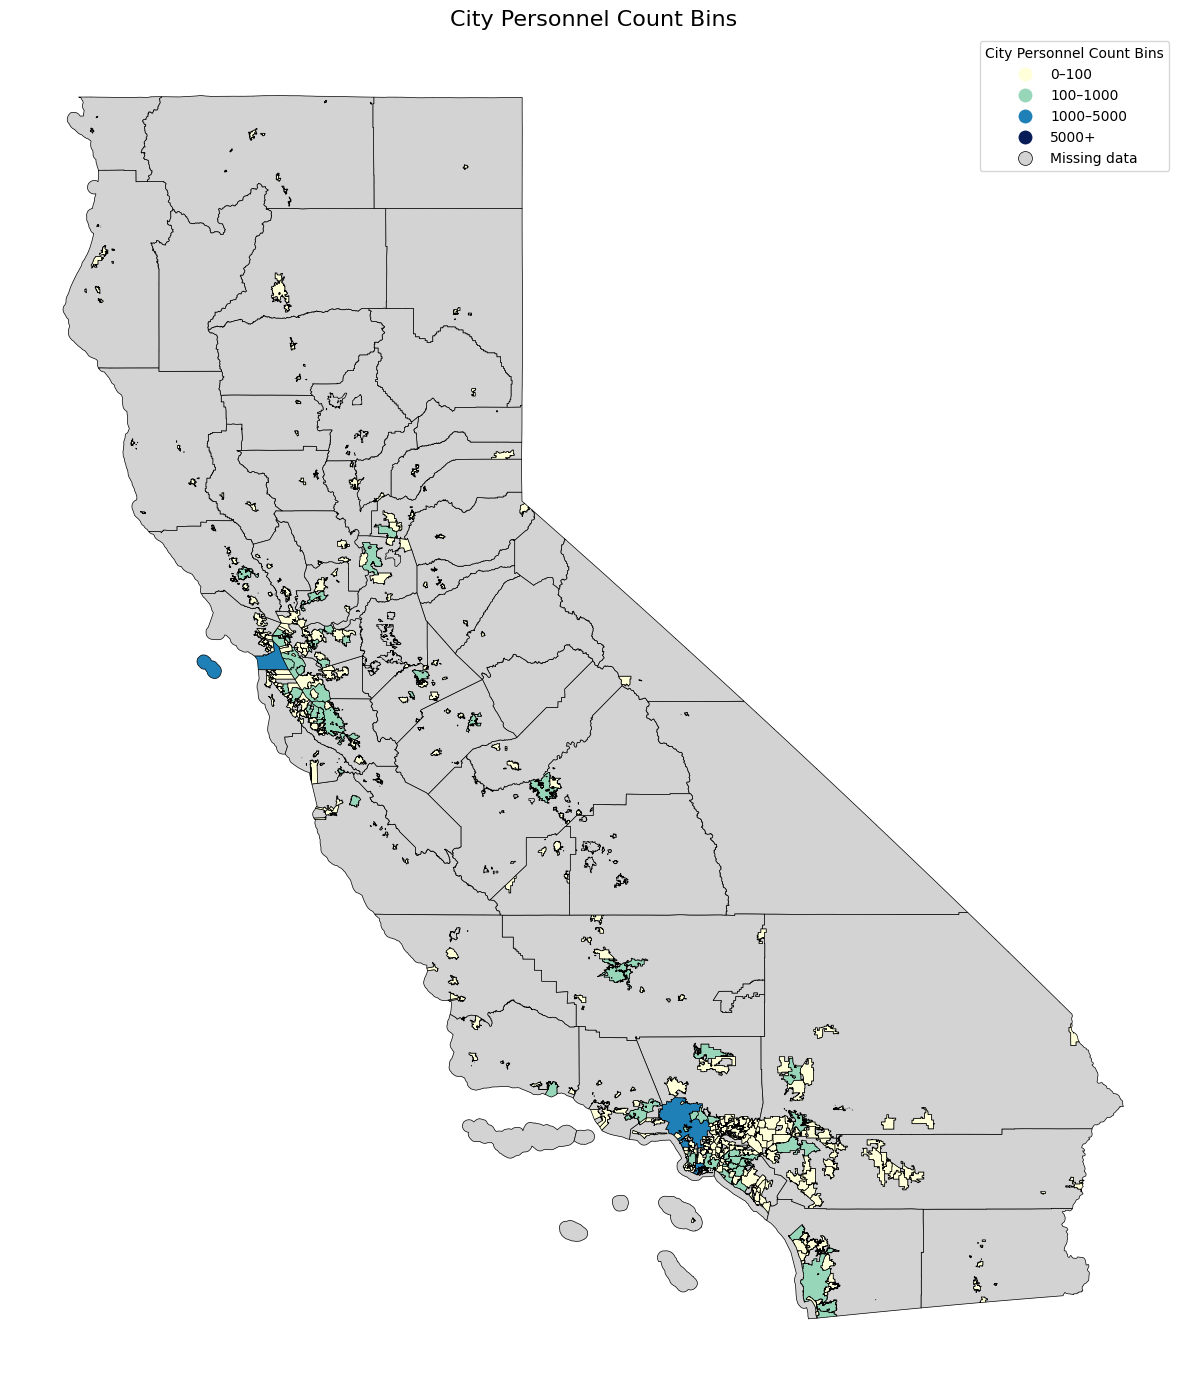

In [123]:
#  County Bins
plot_personnel_map(
    geo_county,
    column='county_personnel_bin',
    title='County Personnel Count Bins',
    cmap='OrRd'
)

#  City Bins
plot_personnel_map(
    geo_city,
    column='city_personnel_bin',
    title='City Personnel Count Bins',
    cmap='YlGnBu'
)

In [99]:
# View Distributions
print("City Personnel Bins Distribution")
print(agg_city_counts_filtered['city_personnel_bin'].value_counts().sort_index())

print("County Personnel Bin Distribution")
print(agg_county_counts_filtered['county_personnel_bin'].value_counts().sort_index())

City Personnel Bins Distribution
city_personnel_bin
0–100        419
100–1000      54
1000–5000      1
5000+          0
Name: count, dtype: int64
County Personnel Bin Distribution
county_personnel_bin
0–100        22
100–1000     25
1000–5000     6
5000+         0
Name: count, dtype: int64
